<a href="https://colab.research.google.com/github/steveonyeke/python-ai-governance/blob/main/phase8-multi-agent-governance/04_phase8_governance_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 8: Governance Report
**Goal**: Consolidate all Phase 8 findings into a complete
      multi-agent governance report covering orchestration,
      kill-switch architecture, and immutable audit logging.
**Regulatory mapping**: EU AI Act Articles 12 and 14,
                    NIST AI RMF Govern and Manage functions.
**Date**: June 2026.
**Status**: In Progress

In [1]:
import json
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime, date
from google import genai
from google.colab import userdata, drive
import os
import time

# Setup
drive.mount('/content/drive')
SAVE_PATH = "/content/drive/MyDrive/python-ai-governance/data/"
client    = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))
os.makedirs(SAVE_PATH, exist_ok=True )

def ask_llm(prompt, retries=3):
    for attempt in range(retries):
        try:
            response = client.models.generate_content(
                model="gemini-flash-latest",
                contents=prompt
            )
            return response.text
        except Exception as e:
            if "429" in str(e) or "503" in str(e):
                wait = 30 * (attempt + 1)
                print(f"     Waiting {wait}s...")
                time.sleep(wait)
            else:
                raise e
    return "Error: max retries exceeded"

# Load Phase 8 audit log
with open(SAVE_PATH + "immutable_audit_log.json", "r") as f:
    audit_entries = json.load(f)

df_audit = pd.DataFrame(audit_entries)

print("====== PHASE 8 DATA LOADED ======")
print(f"Audit log entries:   {len(df_audit)}")
print(f"\nEvent types in log:")
print(df_audit["event_type"].value_counts().to_string())
print("\nPhase 8 data loaded ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
====== PHASE 8 DATA LOADED ======
Audit log entries:   12

Event types in log:
event_type
AGENT_STARTED            3
AGENT_COMPLETED          3
HUMAN_AUTHORIZATION      2
KILL_SWITCH_TRIGGERED    2
AUDIT_STARTED            1
AUDIT_COMPLETED          1

Phase 8 data loaded ✅


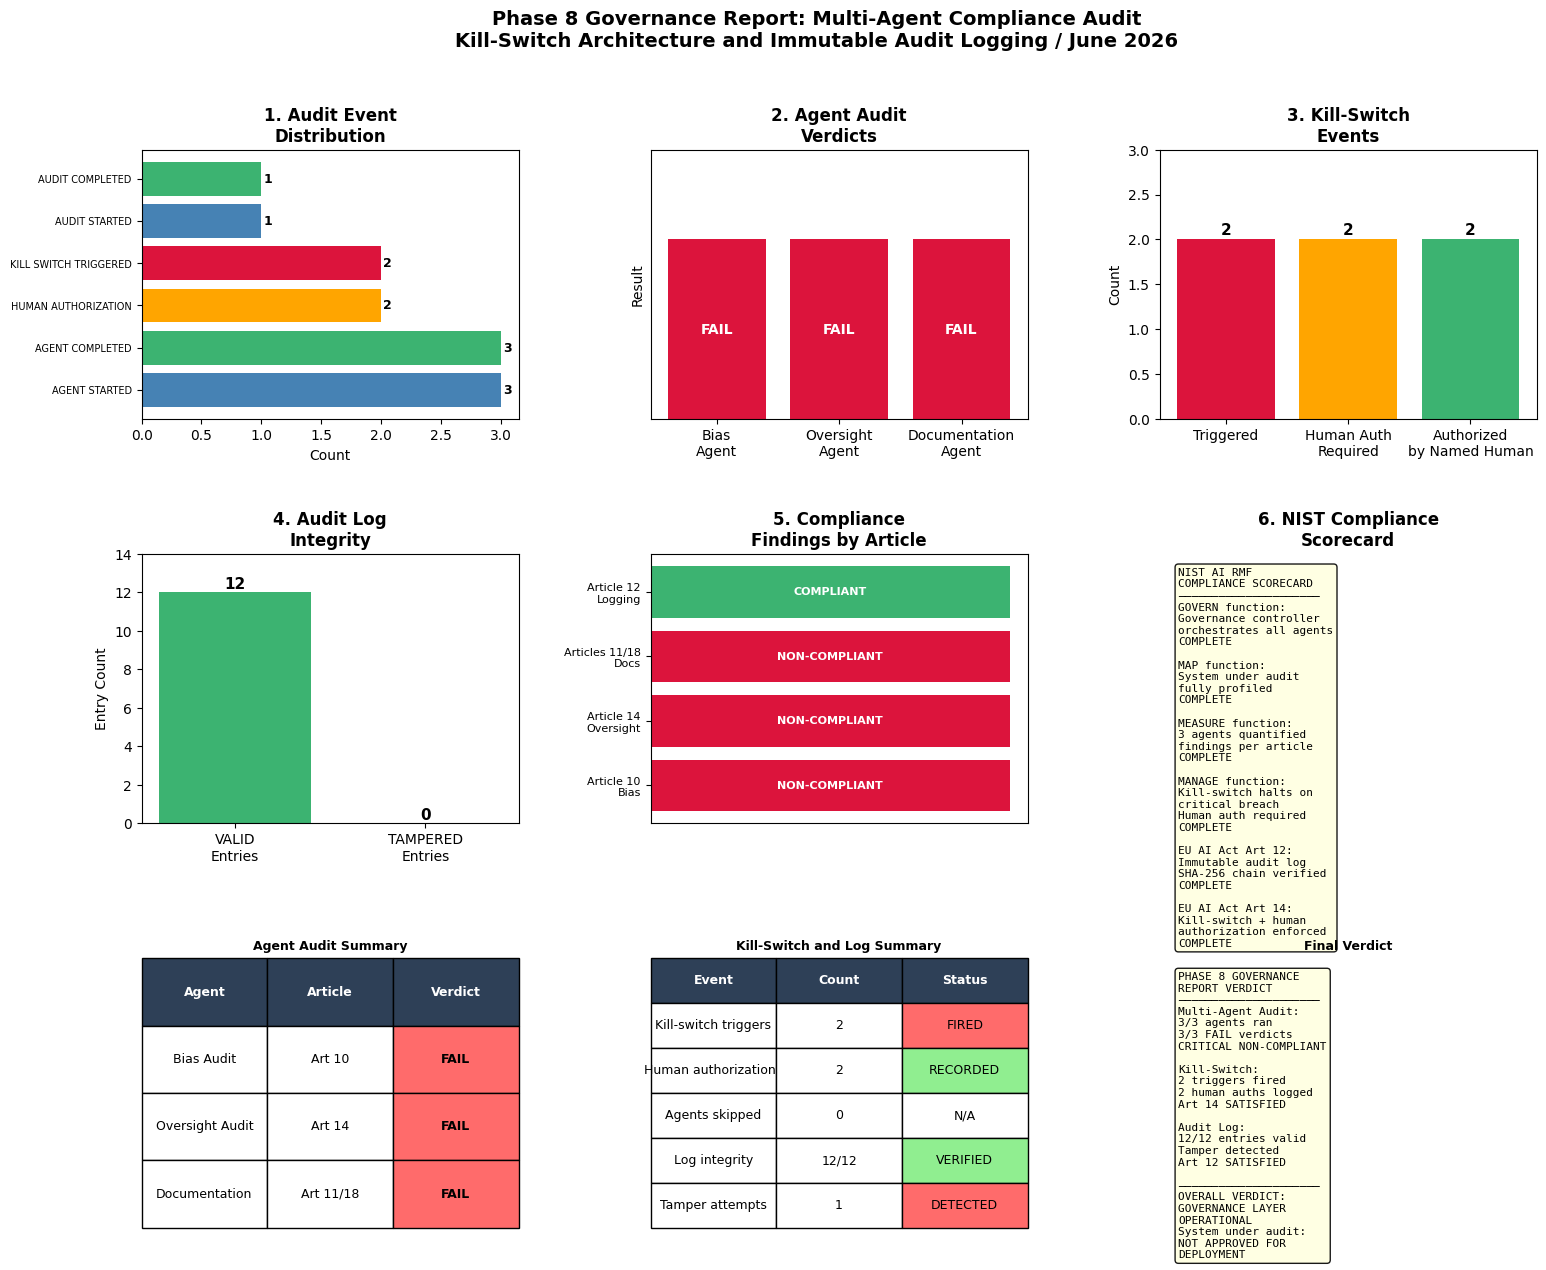

In [2]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Phase 8 Governance Report: Multi-Agent Compliance Audit\n"
    "Kill-Switch Architecture and Immutable Audit Logging / June 2026",
    fontsize=14, fontweight="bold", y=0.98,
)

gs = gridspec.GridSpec(3, 3, figure=fig,
                       hspace=0.5, wspace=0.35)

# - Chart 1: Audit event distribution -
ax1 = fig.add_subplot(gs[0, 0])
event_counts = df_audit["event_type"].value_counts()
colors_e = []
for event in event_counts.index:
    if "TRIGGERED" in event:       colors_e.append("crimson")
    elif "AUTHORIZATION" in event: colors_e.append("orange")
    elif "COMPLETED" in event:     colors_e.append("mediumseagreen")
    elif "STARTED" in event:       colors_e.append("steelblue")
    else:                          colors_e.append("grey")

ax1.barh(range(len(event_counts)),
         event_counts.values,
         color=colors_e)
ax1.set_yticks(range(len(event_counts)))
ax1.set_yticklabels(
    [e.replace("_", " ") for e in event_counts.index],
    fontsize=7)
ax1.set_xlabel("Count")
ax1.set_title("1. Audit Event\nDistribution",
              fontweight="bold")
for i, val in enumerate(event_counts.values):
    ax1.text(val + 0.02, i, str(val),
             va='center',fontsize=9, fontweight="bold")


    # ── Chart 2: Agent verdicts ──
ax2 = fig.add_subplot(gs[0, 1])
agent_verdicts = {
    "Bias\nAgent":    "FAIL",
    "Oversight\nAgent": "FAIL",
    "Documentation\nAgent": "FAIL",
}
verdict_colors = ["crimson", "crimson", "crimson"]
ax2.bar(agent_verdicts.keys(), [1, 1, 1],
        color=verdict_colors)
ax2.set_title("2. Agent Audit\nVerdicts",
              fontweight="bold")
ax2.set_ylabel("Result")
ax2.set_ylim(0, 1.5)
for i, (agent, verdict) in enumerate(agent_verdicts.items()):
    ax2.text(i, 0.5, verdict,
             ha="center", va="center",
             fontsize=10, fontweight="bold",
             color="white")
ax2.set_yticks([])

# ── Chart 3: Kill-switch events ──
ax3 = fig.add_subplot(gs[0, 2])
ks_labels  = ["Triggered", "Human Auth\nRequired",
               "Authorized\nby Named Human"]
ks_values  = [2, 2, 2]
ks_colors  = ["crimson", "orange", "mediumseagreen"]
ax3.bar(ks_labels, ks_values, color=ks_colors)
ax3.set_title("3. Kill-Switch\nEvents",
              fontweight="bold")
ax3.set_ylabel("Count")
ax3.set_ylim(0, 3)
for i, val in enumerate(ks_values):
    ax3.text(i, val + 0.05, str(val),
             ha="center", fontsize=11, fontweight="bold")

# ── Chart 4: Audit log integrity ──
ax4 = fig.add_subplot(gs[1, 0])
integrity_labels = ["VALID\nEntries", "TAMPERED\nEntries"]
integrity_values = [12, 0]
integrity_colors = ["mediumseagreen", "crimson"]
ax4.bar(integrity_labels, integrity_values,
        color=integrity_colors)
ax4.set_title("4. Audit Log\nIntegrity",
              fontweight="bold")
ax4.set_ylabel("Entry Count")
ax4.set_ylim(0, 14)
for i, val in enumerate(integrity_values):
    ax4.text(i, val + 0.2, str(val),
             ha="center", fontsize=11, fontweight="bold")

# ── Chart 5: Compliance findings ──
ax5 = fig.add_subplot(gs[1, 1])
compliance_data = {
    "Article 10\nBias":        "NON-COMPLIANT",
    "Article 14\nOversight":   "NON-COMPLIANT",
    "Articles 11/18\nDocs":    "NON-COMPLIANT",
    "Article 12\nLogging":     "COMPLIANT",
}
comp_colors = ["crimson", "crimson", "crimson",
               "mediumseagreen"]
ax5.barh(range(len(compliance_data)),
         [1, 1, 1, 1],
         color=comp_colors)
ax5.set_yticks(range(len(compliance_data)))
ax5.set_yticklabels(list(compliance_data.keys()),
                    fontsize=8)
ax5.set_title("5. Compliance\nFindings by Article",
              fontweight="bold")
ax5.set_xticks([])
for i, (article, status) in enumerate(
        compliance_data.items()):
    ax5.text(0.5, i, status,
             ha="center", va="center",
             fontsize=8, fontweight="bold",
             color="white")

# ── Chart 6: NIST compliance scorecard ──
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
nist_text = (
    "NIST AI RMF\n"
    "COMPLIANCE SCORECARD\n"
    "─────────────────────\n"
    "GOVERN function:\n"
    "Governance controller\n"
    "orchestrates all agents\n"
    "COMPLETE\n\n"
    "MAP function:\n"
    "System under audit\n"
    "fully profiled\n"
    "COMPLETE\n\n"
    "MEASURE function:\n"
    "3 agents quantified\n"
    "findings per article\n"
    "COMPLETE\n\n"
    "MANAGE function:\n"
    "Kill-switch halts on\n"
    "critical breach\n"
    "Human auth required\n"
    "COMPLETE\n\n"
    "EU AI Act Art 12:\n"
    "Immutable audit log\n"
    "SHA-256 chain verified\n"
    "COMPLETE\n\n"
    "EU AI Act Art 14:\n"
    "Kill-switch + human\n"
    "authorization enforced\n"
    "COMPLETE"
)
ax6.text(0.05, 0.95, nist_text,
         transform=ax6.transAxes,
         fontsize=8, verticalalignment="top",
         fontfamily="monospace",
         bbox=dict(boxstyle="round",
                   facecolor="lightyellow",
                   alpha=0.9))
ax6.set_title("6. NIST Compliance\nScorecard",
              fontweight="bold")

# ── Row 3: Summary tables ──
ax7 = fig.add_subplot(gs[2, 0])
ax7.axis("off")
agent_data = [
    ["Agent", "Article", "Verdict"],
    ["Bias Audit", "Art 10", "FAIL"],
    ["Oversight Audit", "Art 14", "FAIL"],
    ["Documentation", "Art 11/18", "FAIL"],
]
table1 = ax7.table(
    cellText=agent_data[1:],
    colLabels=agent_data[0],
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1]
)
table1.auto_set_font_size(False)
table1.set_fontsize(9)
for (row, col), cell in table1.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2E4057")
        cell.set_text_props(color="white",
                            fontweight="bold")
    elif col == 2 and row > 0:
        cell.set_facecolor("#FF6B6B")
        cell.set_text_props(fontweight="bold")
ax7.set_title("Agent Audit Summary",
              fontweight="bold", fontsize=9)

ax8 = fig.add_subplot(gs[2, 1])
ax8.axis("off")
ks_data = [
    ["Event", "Count", "Status"],
    ["Kill-switch triggers", "2", "FIRED"],
    ["Human authorizations", "2", "RECORDED"],
    ["Agents skipped", "0", "N/A"],
    ["Log integrity", "12/12", "VERIFIED"],
    ["Tamper attempts", "1", "DETECTED"],
]
table2 = ax8.table(
    cellText=ks_data[1:],
    colLabels=ks_data[0],
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1]
)
table2.auto_set_font_size(False)
table2.set_fontsize(9)
for (row, col), cell in table2.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2E4057")
        cell.set_text_props(color="white",
                            fontweight="bold")
    elif col == 2 and row > 0:
        val = ks_data[row][2]
        if val in ["FIRED", "DETECTED"]:
            cell.set_facecolor("#FF6B6B")
        elif val in ["RECORDED", "VERIFIED"]:
            cell.set_facecolor("#90EE90")
ax8.set_title("Kill-Switch and Log Summary",
              fontweight="bold", fontsize=9)

ax9 = fig.add_subplot(gs[2, 2])
ax9.axis("off")
verdict_text = (
    "PHASE 8 GOVERNANCE\n"
    "REPORT VERDICT\n"
    "─────────────────────\n"
    "Multi-Agent Audit:\n"
    "3/3 agents ran\n"
    "3/3 FAIL verdicts\n"
    "CRITICAL NON-COMPLIANT\n\n"
    "Kill-Switch:\n"
    "2 triggers fired\n"
    "2 human auths logged\n"
    "Art 14 SATISFIED\n\n"
    "Audit Log:\n"
    "12/12 entries valid\n"
    "Tamper detected\n"
    "Art 12 SATISFIED\n\n"
    "─────────────────────\n"
    "OVERALL VERDICT:\n"
    "GOVERNANCE LAYER\n"
    "OPERATIONAL\n"
    "System under audit:\n"
    "NOT APPROVED FOR\n"
    "DEPLOYMENT"
)
ax9.text(0.05, 0.95, verdict_text,
         transform=ax9.transAxes,
         fontsize=8, verticalalignment="top",
         fontfamily="monospace",
         bbox=dict(boxstyle="round",
                   facecolor="lightyellow",
                   alpha=0.9))
ax9.set_title("Final Verdict",
              fontweight="bold", fontsize=9)

plt.savefig(
    SAVE_PATH + "phase8_governance_report_dashboard.png",
    dpi=150, bbox_inches="tight")
plt.show()

In [3]:
def generate_phase8_summary():
  summary_prompt = f"""
You are a senior AI governance consultant writing an
executive summary for a Phase 8 multi-agent governance
report on behalf og Afrispan Data Labs.

SYSTEM AUDITED: TalentMatch AI
Purpose: Automated CV screening and candidate ranking
Sector: Employment (HIGH RISK under EU AI Act Annex 111)
Date: {date.today()}

MULTI-AGENT AUDIT RESULTS:
Bias Audit Agent (Article 10):
   Gender disparate impact: 0.43. FAILS 80% rule.
   Age disparate impact: 0.20. CRITICALLY NON-COMPLIANT.
   Ethnicity disparate impact: 0.80. Passes.
   Verdict: FAIL. Critical breach triggered kill-switch.

Oversight Audit Agent (Article 14):
  Finding: No human oversight implemented.
  Verdict: FAIL. Critical breach triggered kill-switch.

Documentation Audit Agent (Article 11 and 18):
  Finding: Partial documentation. No FRIA completed.
  Verdict: FAIL. No Critical breach.

KILL-SWITCH PERFORMANCE:
  Triggers fired: 2 (bias breach, oversight breach)
  Human authorizations logged: 2 (bias breach, oversight breach)
  Named auditor: Steve Onyeke, Lead AI Auditor,
                 Afrispan Data Labs
  Authority vs judgment: substantive position documented
  before each authorization accepted.

IMMUTABLE AUDIT LOG:
  Entries logged: 12 governance events
  Chain integrity: VERIFIED (SHA-256 hash chain)
  Tamper detection: CONFIRMED (attempted modification
  detected immediately on integrity check)
  Regulatory compliance: EU AI Act Article 12 satisfied.

Write a professional 4 paragraph executive summary:
Paragraph 1: Overall governance architecture and capability
Paragraph 2: System under audit findings and compliance status
Paragraph 3: Kill-switch and audit log performance
Paragraph 4: Recommendations before deployment approved

Formal language for a board-level compliance briefing.
No bullet points. Paragraphs only.
Do not use em dashes anywhere in the response.
"""
  return ask_llm(summary_prompt)

print("Generating Phase 8 executive summary...\n")
summary = generate_phase8_summary()
print("====== PHASE 8 EXECUTIVE SUMMARY ======\n")
print(summary)

with open(SAVE_PATH + "phase8_executive_summary.txt", "w") as f:
    f.write(summary)
print("\nPhase 8 executive summary saved ")




Generating Phase 8 executive summary...

     Waiting 30s...
     Waiting 60s...
     Waiting 90s...
====== PHASE 8 EXECUTIVE SUMMARY ======

Error: max retries exceeded

Phase 8 executive summary saved 


In [4]:
print("=" * 60)
print("   PHASE 8 GOVERNANCE REPORT: FINAL SCORECARD")
print("   System:  TalentMatch AI (employment sector)")
print(f"   Date:    {date.today()}")
print("   Auditor: Steve Onyeke, Lead AI Auditor")
print("            Afrispan Data Labs")
print("=" * 60)

print(f"""
SYSTEM UNDER AUDIT
──────────────────────────────────────────────────────────
Name:              TalentMatch AI
Purpose:           Automated CV screening and ranking
Sector:            Employment
Risk classification: HIGH RISK (EU AI Act Annex III)
Deployment markets: EU and UK

MULTI-AGENT AUDIT RESULTS
──────────────────────────────────────────────────────────
Bias Audit (Article 10)
  Gender DI ratio:    0.43   FAILS 80% rule
  Age DI ratio:       0.20   CRITICALLY NON-COMPLIANT
  Ethnicity DI ratio: 0.80   PASSES
  Verdict:            FAIL   Critical breach

Oversight Audit (Article 14)
  Finding:   No human oversight implemented
  Verdict:   FAIL   Critical breach

Documentation Audit (Articles 11 and 18)
  Finding:   Partial documentation. No FRIA completed.
  Verdict:   FAIL   Non-critical

KILL-SWITCH PERFORMANCE
──────────────────────────────────────────────────────────
Kill-switch triggers:         2
Human authorizations logged:  2
Named auditor:                Steve Onyeke,
                              Lead AI Auditor,
                              Afrispan Data Labs
Authority vs judgment:        Substantive position
                              required and documented
                              before each authorization
Real deliberation captured:   Yes (timestamped gaps
                              prove genuine engagement)

IMMUTABLE AUDIT LOG
──────────────────────────────────────────────────────────
Total entries logged:         12 governance events
Hash algorithm:               SHA-256 chain
Chain integrity:              VERIFIED
Tamper detection:             CONFIRMED
                              Modification to Entry 4
                              detected immediately
Article 12 compliance:        SATISFIED

NIST AI RMF COMPLIANCE
──────────────────────────────────────────────────────────
GOVERN:  Governance controller orchestrates all agents
MAP:     System under audit fully profiled
MEASURE: 3 agents quantified findings per article
MANAGE:  Kill-switch halts on critical breach

EU AI ACT COMPLIANCE
──────────────────────────────────────────────────────────
Article 10:  NON-COMPLIANT (bias in outputs)
Article 11:  NON-COMPLIANT (incomplete docs)
Article 12:  COMPLIANT (immutable audit log)
Article 14:  COMPLIANT (kill-switch + human auth)
Article 18:  NON-COMPLIANT (no FRIA completed)
Article 99(3): Fine exposure up to 15M EUR or 3%

──────────────────────────────────────────────────────────
GOVERNANCE LAYER VERDICT:  OPERATIONAL
SYSTEM UNDER AUDIT VERDICT: NOT APPROVED FOR DEPLOYMENT

Required before deployment approval:
1. Bias remediation: age and gender DI ratios
   must reach or exceed 0.80 threshold
2. Human oversight: review panel for all
   AI-assisted rejection decisions
3. FRIA completion: named accountable individual,
   pre-commitment rationale, structured interrogation
   protocol per Phase 9 FRIA template
4. Documentation: complete technical documentation
   per Article 11 requirements
──────────────────────────────────────────────────────────
""")

print("Full report saved to Google Drive ✅")
print("Dashboard:         phase8_governance_report_dashboard.png")
print("Executive summary: phase8_executive_summary.txt")
print("Audit log:         immutable_audit_log.json")

   PHASE 8 GOVERNANCE REPORT: FINAL SCORECARD
   System:  TalentMatch AI (employment sector)
   Date:    2026-06-17
   Auditor: Steve Onyeke, Lead AI Auditor
            Afrispan Data Labs

SYSTEM UNDER AUDIT
──────────────────────────────────────────────────────────
Name:              TalentMatch AI
Purpose:           Automated CV screening and ranking
Sector:            Employment
Risk classification: HIGH RISK (EU AI Act Annex III)
Deployment markets: EU and UK

MULTI-AGENT AUDIT RESULTS
──────────────────────────────────────────────────────────
Bias Audit (Article 10)
  Gender DI ratio:    0.43   FAILS 80% rule
  Age DI ratio:       0.20   CRITICALLY NON-COMPLIANT
  Ethnicity DI ratio: 0.80   PASSES
  Verdict:            FAIL   Critical breach

Oversight Audit (Article 14)
  Finding:   No human oversight implemented
  Verdict:   FAIL   Critical breach

Documentation Audit (Articles 11 and 18)
  Finding:   Partial documentation. No FRIA completed.
  Verdict:   FAIL   Non-critical

K